# A6

## Group Project - see Canvas for group allocations

- Complete the following and submit to Canvas before Oct 31 11:59PM,
- Late work will recieve 0%,
- Each assignment is worth the same, 
- Please get in contact with the instructor in plenty of time if you need help,
- Before submitting your work, make sure to check everything runs as expected. Click **Kernel > Restart Kernel and Run All Cells**.
- Feel free to add more cells to experiment or test your answers,
- I encourage you to discuss the course material and assignment questions with your classmates. However, unless otherwise explicitly stated on the assignment, you must complete and write up your solutions on your own,
- The use of GenAI is prohibited as outlined in the course syllabus. If I suspect you of cheating, you may be asked to complete a written or oral exam on the content of this assignment,
- ✍ indicates a question where a mathematical proof is required
- 💻 indicates a question where numerical experiments are required 

<div class="alert alert-info">
Enter your names here: YOUR NAME HERE  

Approximate time spent on this assignment: .......
</div>

<div class="alert alert-block alert-danger"> 
    ⚠ Do not edit the following cell. You may find some of these functions useful
</div>

In [1]:
# | code-fold: true
# useful definitions that we've used so far:

using Plots
using LaTeXStrings
using Polynomials
using PrettyTables

function simple_iteration( g, x1; N=100, tol=1e-10 )
    x = [ x1 ]
    for n in 2:N
        push!( x, g(x[n-1]) )
        if (abs(g(x[end]) - x[end]) < tol)
            break
        elseif (x[end] == Inf)
            @warn "simple iteration diverges to Inf";
            break
        elseif (x[end] == -Inf)
            @warn "simple iteration diverges to -Inf";
            break
        end 
    end
    return x
end

function relaxation( f, λ, x1; N=100, tol=1e-10)
    x = [x1]
    r = 0.;
    for n in 2:N
        push!( x, x[n-1] - λ*f(x[n-1]) )
        r = abs(f(x[end]));
        if (r < tol)
            return x
        end
    end
    @warn "max interations with |f| = $r";
    return x
end

function Newton( f, f_prime, x1; N=100, tol=1e-10)
    x = [x1]
    for n in 2:N
        push!( x, x[n-1] - f(x[n-1])/f_prime(x[n-1]) )
        r = abs(f(x[end]));
        if (r < tol)
            return x
        end
    end
    @warn "max interations |f| = $r";
    return x
end

function orderOfConvergence( x, ξ; α=0 )
    err = @. abs(x - ξ)
    logerr = @. log10( err )
    ratios = [NaN; [logerr[i+1] / logerr[i] for i in 1:length(logerr)-1]]
    if (α == 0) 
        α = ratios[end]
        αr = round(α, sigdigits=3)
    end
    mu = [NaN; [err[i+1] / err[i]^α for i in 1:length(err)-1]]
    pretty_table( 
         [1:length(x) err logerr ratios mu];
        column_labels = ["iteration", "absolute error", "log error", "alpha", "mu (α = $α)" ]
    )
end

function μ( x, ξ; α=1 )
    return @. abs( x[2:end] - ξ ) / ( abs(x[1:end-1] - ξ )^α );
end 

ϵ = 1.;
f = ψ -> ψ - ϵ * sin(ψ) - 2π; # has a zero at 2π
df = ψ -> 1 - ϵ * cos(ψ)
ξ = 2π

6.283185307179586

In [3]:
g = x -> x^2 - 2
dg = x -> 2x
orderOfConvergence( Newton( g, dg, 1. ), sqrt(2) ) 

┌───────────┬────────────────┬───────────┬─────────┬────────────────────────────
│ iteration │ absolute error │ log error │   alpha │ mu (α = 2.079604050288125 ⋯
├───────────┼────────────────┼───────────┼─────────┼────────────────────────────
│       1.0 │       0.414214 │ -0.382776 │     NaN │                         N ⋯
│       2.0 │      0.0857864 │  -1.06658 │ 2.78644 │                     0.536 ⋯
│       3.0 │      0.0024531 │  -2.61028 │ 2.44734 │                    0.4053 ⋯
│       4.0 │      2.1239e-6 │  -5.67287 │ 2.17328 │                    0.5694 ⋯
│       5.0 │    1.59472e-12 │  -11.7973 │  2.0796 │                         1 ⋯
└───────────┴────────────────┴───────────┴─────────┴────────────────────────────
                                                                1 column omitted


## B. Kepler's Equation

In lectures, we considered the equation 

\begin{align}
    f(\psi) := \psi - \epsilon \sin \psi - 2\pi = 0
\end{align}

with $\epsilon = 0.9$. Recall that we showed that the Relaxation Method ($x_{n+1} = x_n - \lambda f(x_n)$) converged linearly with asymptotic error constant $\left| 1 - 0.1 \lambda \right|$ and Newton's Method converged faster than quadratically. For the remainder of this question, fix $\epsilon = 1$. Here's a plot of $f$:

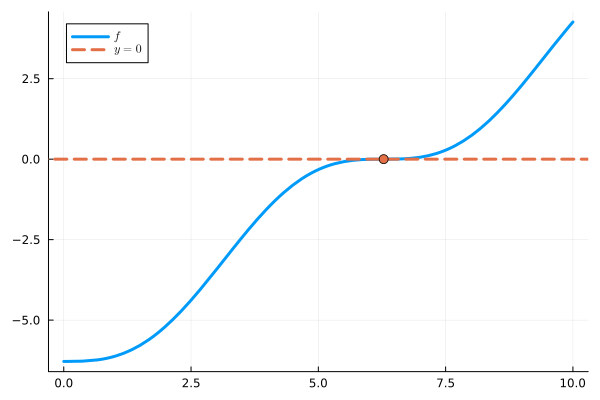

In [2]:
plot( f, 0, 10, label=L"f", lw=3 )
hline!( [0] , linestyle=:dash, lw = 3, label=L"y=0")
scatter!( [ξ], [f(ξ)], markersize=5, primary=false )

1. ✍ Show that $2\pi$ is the unique solution to $f = 0$.
2. 💻 Show numerically that the relaxation method converges for some choice of $\lambda$. What is the order of convergence of this method?
3. 💻 Show numerically that Newton's method converges. What is the order of convergence?
4. ✍ Compare your answers to this question to the $\epsilon = 0.9$ case. Why is the convergence slower/faster?

In [7]:
orderOfConvergence( Newton(f, df, 6.), 2π; α=1  )

┌───────────┬────────────────┬───────────┬─────────┬────────────┐
│ iteration │ absolute error │ log error │   alpha │ mu (α = 1) │
├───────────┼────────────────┼───────────┼─────────┼────────────┤
│       1.0 │       0.283185 │ -0.547929 │     NaN │        NaN │
│       2.0 │       0.188537 │ -0.724603 │ 1.32244 │   0.665773 │
│       3.0 │       0.125617 │ -0.900952 │ 1.24337 │   0.666271 │
│       4.0 │      0.0837225 │  -1.07716 │ 1.19558 │   0.666491 │
│       5.0 │      0.0558085 │   -1.2533 │ 1.16352 │   0.666589 │
│       6.0 │      0.0372037 │  -1.42941 │ 1.14052 │   0.666632 │
│       7.0 │      0.0248019 │  -1.60551 │  1.1232 │   0.666651 │
│       8.0 │      0.0165344 │  -1.78161 │ 1.10968 │    0.66666 │
│       9.0 │      0.0110229 │   -1.9577 │ 1.09884 │   0.666664 │
│      10.0 │     0.00734859 │   -2.1338 │ 1.08995 │   0.666665 │
│      11.0 │     0.00489906 │  -2.30989 │ 1.08253 │   0.666666 │
│      12.0 │     0.00326604 │  -2.48598 │ 1.07623 │   0.666666 │
│      13.

## D. Research Task

Find a research paper explaining a method named after one of the following people: Halley, Householder, Osada, Ostrowski, Steffensen, Traub. What is the main novelty of this method? How does it (claim to) improve upon previous methods in the literature? Implement your chosen method and test it on a function of your choice. 

Please clearly cite which paper you are describing.